Time-Frequency Representation (TFR) Sanity Check

This notebook visualizes the Event-Related Spectral Perturbations (ERSP) 
calculated via complex Morlet wavelets in script 09. 
It acts as a diagnostic tool to verify that the frequency bands 
(Theta, Alpha, Beta, Gamma) and temporal baselines are mathematically 
sound and visually free of extreme hardware artifacts prior to statistical testing.

In [1]:
import mne
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve the absolute path to the time-frequency HDF5 output directory
output_dir = Path('../../output/analysis/time_frequency').resolve()
print(f"Looking for TFR binaries in: {output_dir}")

# Define the target dyad for visual inspection
subject_id = '01'
p1_file = output_dir / f"sub-{subject_id}_P1_tfr.h5"
p2_file = output_dir / f"sub-{subject_id}_P2_tfr.h5"

Looking for TFR files in: C:\Users\Ayush Batra\Documents\College\EEG\eeg-bala-sharks\output\analysis\time_frequency


Reading C:\Users\Ayush Batra\Documents\College\EEG\eeg-bala-sharks\output\analysis\time_frequency\sub-01_P1_tfr.h5 ...

=== Player 1 (sub-01) ===
Total Channels: 64
Frequencies evaluated: 4.0 Hz to 40.0 Hz
Time range: -0.20 sec to 5.00 sec

Applying baseline correction (mode: logratio)


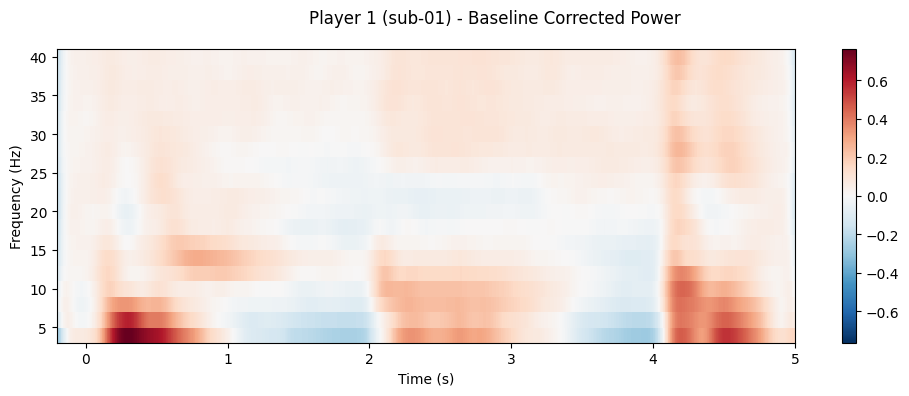

Reading C:\Users\Ayush Batra\Documents\College\EEG\eeg-bala-sharks\output\analysis\time_frequency\sub-01_P2_tfr.h5 ...

=== Player 2 (sub-01) ===
Total Channels: 64
Frequencies evaluated: 4.0 Hz to 40.0 Hz
Time range: -0.20 sec to 5.00 sec

Applying baseline correction (mode: logratio)


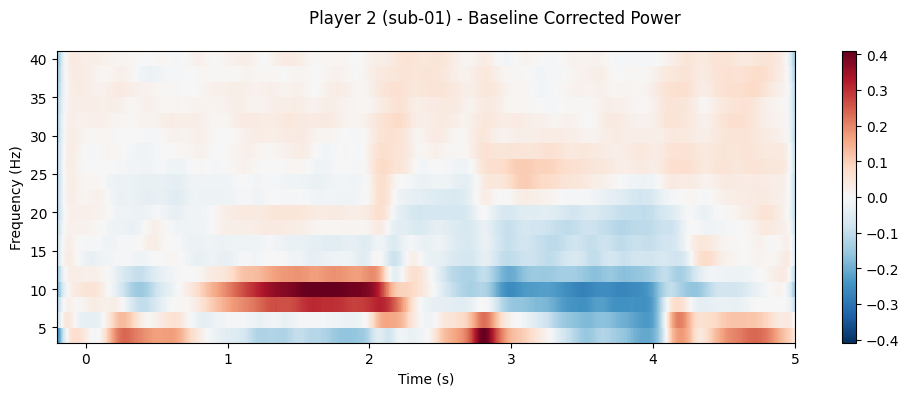

In [7]:
def plot_tfr_sanity_check(tfr_path, player_name):
    """
    Loads the multidimensional HDF5 TFR object and plots the grand average power spectrum.
    
    Applies a 'logratio' baseline correction (decibel conversion) relative to the 
    pre-stimulus period (-0.2s to 0s). This standardizes brainwave power, allowing 
    researchers to clearly see task-induced Event-Related Synchronization (red/warm) 
    or Desynchronization (blue/cool).
    """
    if not tfr_path.exists():
        print(f"File not found: {tfr_path.name}")
        return
        
    print(f"Reading {tfr_path} ...")
    
    # Load the precomputed Time-Frequency object generated by the pipeline
    tfr = mne.time_frequency.read_tfrs(tfr_path)[0]
    
    # Output technical metadata for academic verification
    print(f"\n=== {player_name} (sub-{subject_id}) ===")
    print(f"Total Channels: {len(tfr.ch_names)}")
    print(f"Frequencies evaluated: {tfr.freqs[0]:.1f} Hz to {tfr.freqs[-1]:.1f} Hz")
    print(f"Time range: {tfr.times[0]:.2f} sec to {tfr.times[-1]:.2f} sec\n")
    
    print("Applying baseline correction (mode: logratio)")
    
    # Render the Time-Frequency heatmap
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plotting across all EEG channels. 
    # Vmin/Vmax constraints prevent singular localized artifacts from blowing out the color scale.
    tfr.plot(
        baseline=(-0.2, 0),    # Calibrate against the pre-decision resting state
        mode='logratio',       # Transform to decibels (dB)
        title=f"Time-Frequency Power: {player_name} (sub-{subject_id})",
        axes=ax,
        show=False,
        vmin=-1.5,             
        vmax=1.5
    )
    
    # Add visual reference overlay indicating exact Stimulus Onset (t=0)
    ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.8)
    
    plt.tight_layout()
    plt.show()

# Execute plotting diagnostic for both players in the dyad
plot_tfr_sanity_check(p1_file, "Player 1")
plot_tfr_sanity_check(p2_file, "Player 2")